Text(0.5, 1.0, '每年上映的电影数量')

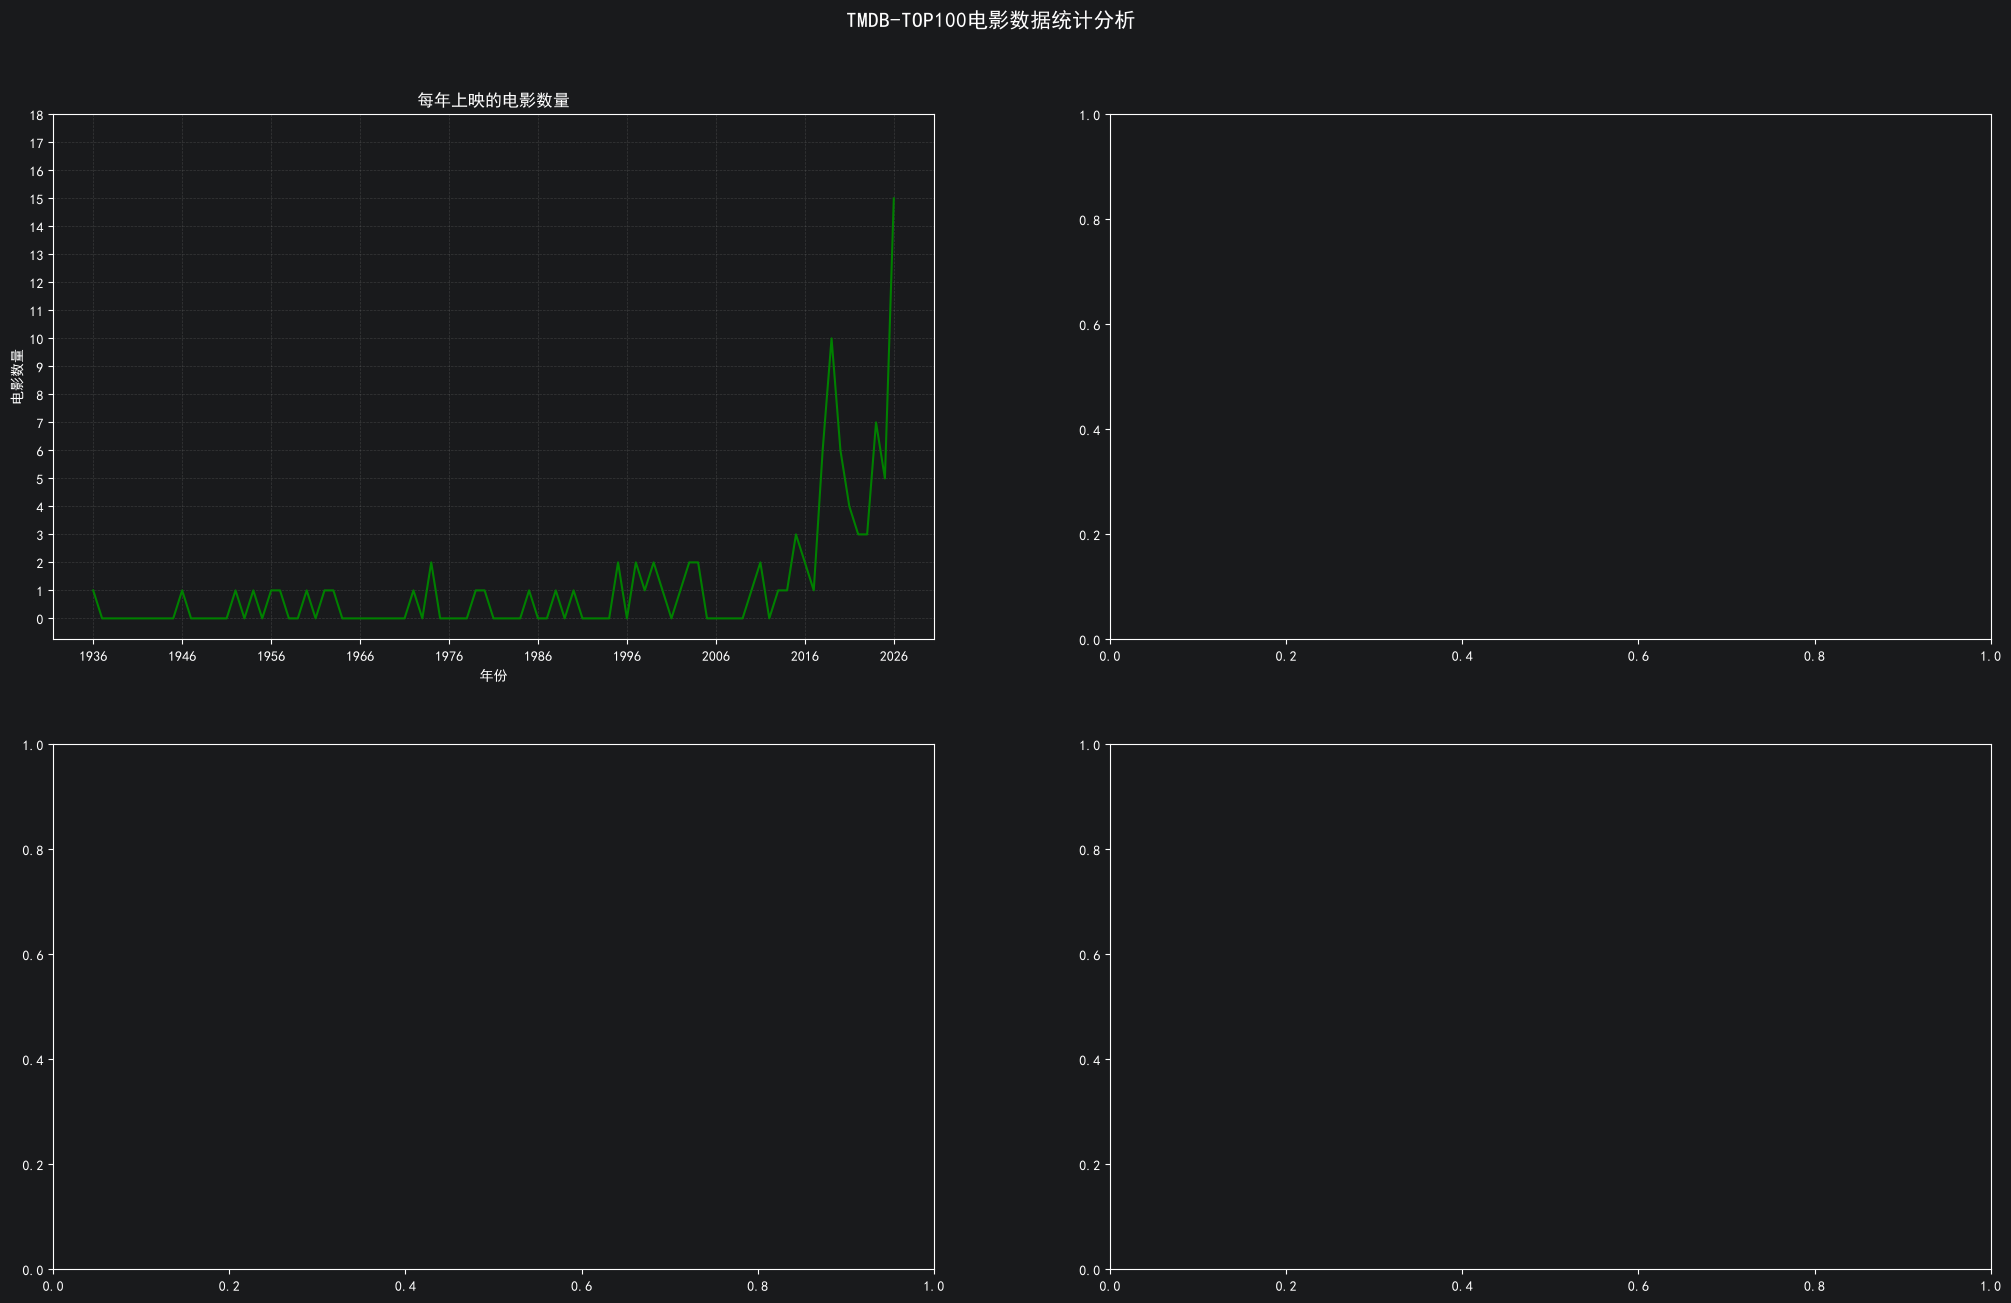

In [90]:
from matplotlib.axes import Axes
#基础环境配置
import pandas as pd
import matplotlib.pyplot as plt

#让matplotlib 能够正确显示中文字符
plt.rcParams['font.sans-serif'] = ['SimHei']

#创建带有4个子图的画布
fig, ax = plt.subplots(2, 2, figsize=(25, 15), dpi=100)

#设置整个画布的标题
fig.suptitle('TMDB-TOP100电影数据统计分析', fontsize=15, x=0.5, y=0.95)

#获取4个子图对象
ax1: Axes = ax[0, 0]
ax2: Axes = ax[0, 1]
ax3: Axes = ax[1, 0]
ax4: Axes = ax[1, 1]

#pd读取数据(Int64:整数类型支持空值)
df = pd.read_csv('data/movies_info3.csv', usecols=['电影名', '年份', '上映时间', '类型', '时常', '评分', '语言'],
                 dtype={'年份': 'Int64'})

# 需求1: 绘制折线图统计每年上映的电影数量

#检查处理年份空值、异常值(筛选)
df.isnull().sum()  #查看是否有空值---有1个
df[(df['年份'] < 1) | (df['年份'] > 2026)]  #查看是否有异常值---无

#补充表格年份空值
df['年份'] = df['上映时间'].str[:4].astype(int)

#获取x轴数据
min_year = df['年份'].min()
max_year = df['年份'].max()
x_year = [year for year in range(min_year, max_year + 1, 1)]

#获取y轴数据
year_count = df.groupby('年份').size()
year_count = [int(year_count.get(year, 0)) for year in x_year]

#绘制折线图
ax1.plot(x_year, year_count, color='green')

#设置x,y轴刻度
ax1.set_xticks(x_year[0::10])
ax1.set_yticks(range(0, 19, 1))

#设置x,y轴标签
ax1.set_xlabel('年份', fontsize=10)
ax1.set_ylabel('电影数量', fontsize=10)

#设置网格
ax1.grid(True, linestyle='--', alpha=0.2)

#设置子图标题
ax1.set_title('每年上映的电影数量', fontsize=12)





